<a href="https://colab.research.google.com/github/MonishDY/AI-Track/blob/main/Capstone%20Project/MonishDY_230701195_Axis_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

insurance.avif

# **AXIS INSURANCE CASE STUDY**

# **Problem Statement**

Leveraging customer information is of paramount importance for most businesses. In the case of an insurance company, the attributes of customers can be crucial in making business decisions. Hence, knowing to explore and generate value out of such data can be an invaluable skill to have.

Suppose you are hired as a Data Scientist in an Insurance company. The company wants to have a detailed understanding of the customer base for one of its Insurance Policy **'MediClaim'**. The idea is to generate insights about the customers and answer a few key questions with statistical evidence, by using the past dataset. The dataset **'AxisInsurance'** contains customers' details like age, sex, charges, etc.

# **Questions to be Answered**

Perform the statistical analysis to answer the following questions using the collected data.

1.	Explore the dataset and extract insights using Exploratory Data Analysis.

2.	Prove(or disprove) that the medical claims made by the people who smoke are greater than those who don't?

3.	Prove (or disprove) with statistical evidence that the BMI of females is different from that of males.

4.  Does the smoking habit of customers depend on their region?  (**Hint:** Create a contingency table using the pandas.crosstab() function]

5. Is the mean BMI of women with no children, one child, and two children the same? Explain your answer with statistical evidence.

The idea behind answering these questions is to help the company in making evidence-based business decisions.

# **Assumptions**
The Health Insurance Customer's data is a simple random sample from the population data, and the samples are independent of each other.

# **Data Dictionary**

**AxisInsurance.csv**  contains the following information about customers of the Axis Health Insurance.

1.	**Age** - This is an integer indicating the age of the primary beneficiary (excluding those above 64 years, since they are generally covered by the government).

2.	**Sex** - This is the policy holder's gender, either male or female.

3.	**BMI** - This is the body mass index (BMI), which provides a sense of how over or under-weight a person is relative to their height. BMI is equal to weight (in kilograms) divided by height (in meters) squared. An ideal BMI is within the range of 18.5 to 24.9.

4.	**Children** - This is an integer indicating the number of children / dependents covered by the insurance plan.

5.	**Smoker** - This is yes or no depending on whether the insured person regularly smokes tobacco.

6.	**Region** - This is the beneficiary's place of residence in the U.S., divided into four geographic regions - northeast, southeast, southwest, or northwest.

7.	**Charges** - Individual medical costs billed by health insurance

### **Import all the necessary libraries**

Let us import the necessary libraries that helps to answer the given questions

In [1]:
### Import Necessary Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    ttest_ind, chi2_contingency,
    f_oneway, shapiro, levene, norm
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set plot style to whitegrid
sns.set_style("whitegrid")

## **1.	Explore the dataset and extract insights using Exploratory Data Analysis.**

### **Read the data into the notebook**

Let us now read the **AxisInsurance.csv** into the notebook

In [2]:
# Loading the Axis Insurance Dataset
path = r"https://raw.githubusercontent.com/MonishDY/AI-Track/refs/heads/main/Capstone%20Project/AxisInsurance.csv"
data = pd.read_csv(path)

### **View the first and last 5 rows of the dataset**

We'll use the `data.head()` and `data.tail()` for checking whether data is loaded and also check how data looks like.

In [3]:
# Read the first 5 rows of the dataset
data.head()

,age,sex,bmi,children,smoker,region,charges
0,21,female,16.000,1,no,northeast,3167.45585
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Read the last 5 rows of the dataset
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.54830
1334,52,female,46.75,5,no,southeast,12592.53450
1335,54,female,47.41,0,yes,southeast,63770.42801
1336,37,female,47.60,2,yes,southwest,46113.51100
1337,46,female,48.07,2,no,northeast,9432.92530


### **Understand the shape of the dataset**

In [5]:
# Display the shape of the data
print("Shape of the Axis Insurance Dataset (row, column):", data.shape)

Shape of the Axis Insurance Dataset (row, column): (1338, 7)


- *The **AxisInsurance dataset** contains `1338` rows and `7` columns.*

### **Check the data types of the columns for the dataset**

Now we can get the info of the dataset using `data.info()`

In [6]:
# Getting the info of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


We'll just display the datatypes of all columns using `data.dtypes`

In [7]:
# Display the data types of the columns
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


- *We can see we have both numerical and categorical columns in the dataset. The columns **age, bmi, children, charges** are numerical variables and **sex, smoker, region** are categorical variables.*

- *For our better understanding we set the datatype of the categorical variables from **object** to **category**.*

### **Fixing the data types**

To change the datatype of the categorical variables, first we need to identify the categorical variables. So let us store the categorical variables as a list.

In [8]:
# Identify categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns

print("Categorical columns:")
categorical_cols

Categorical columns:


Index(['sex', 'smoker', 'region'], dtype='object')

Now convert the categorical columns to category datatype

In [9]:
# Convert categorical columns to category datatype
data[categorical_cols] = data[categorical_cols].astype('category')

# Verify the data types
data.dtypes

,0
age,int64
sex,category
bmi,float64
children,int64
smoker,category
region,category
charges,float64


Similary we identify the numerical variables in the dataset and store them as well in a separate list.

In [10]:
# Identify numerical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

print("Numerical columns:")
numerical_cols

Numerical columns:


Index(['age', 'bmi', 'children', 'charges'], dtype='object')

### **Check for missing values**

Now we'll check if there is any data missing in the dataset. This step is crucial as any missing data in a dataset will highly affect the model behaviour. So we'll check for null values using `data.isnull()`.

In [11]:
# Check for missing values
missing_values = data.isnull().sum()

print("Missing values in each column:")
missing_values

Missing values in each column:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


- **No missing values were found** in any of the dataset's columns.
- The dataset is complete and does not require any missing value treatment before analysis.

### **Check for duplicate values**

Check whether if any duplicate values exist using `data.duplicated()`

In [12]:
# Check if any duplicate values present in data
duplicate_rows = data.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 1


- **One duplicate record** was identified in the dataset.
- The duplicate record was removed before analysis to avoid redundancy and ensure accurate statistical analysis.

Drop Duplicate data

In [13]:
# Drop the duplicate data
data.drop_duplicates(inplace=True)

# Check the data shape now
data.shape

(1337, 7)

- *Duplicate data is dropped and we get the new dataset with the shape (1337, 7).*

### **Five point summary of continuous variables**

Split the numerical columns into discrete and continuous columns.

In [14]:
# Check the number of unique values in each numerical column
for col in numerical_cols:
    print(f"{col}: {data[col].nunique()} unique values")

age: 47 unique values
bmi: 552 unique values
children: 6 unique values
charges: 1337 unique values


In [15]:
# Continuous and discrete variables
continuous_cols = ['age', 'bmi', 'charges']
discrete_cols = ['children']

print("Continuous variables:", continuous_cols)
print("Discrete variables:", discrete_cols)

Continuous variables: ['age', 'bmi', 'charges']
Discrete variables: ['children']


- There are three continuous variables **(age, bmi, and charges)** and one discrete variable **(children)** in the dataset.
- Continuous variables will be analyzed using distribution plots, while the discrete variable will be examined using count-based visualizations.

Perform the summary of the numerical columns like mean, standard deviation, min value, max value etc.

In [16]:
# Statistical summary for numerical variables
data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.682756,1.095737,13279.121487
std,14.044333,6.147973,1.205571,12110.359656
min,18.000000,14.000000,0.000000,1121.873900
25%,27.000000,26.315000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


- The customers' **ages range from 18 to 64 years**, with a median age of **39 years**, indicating a balanced distribution of adults across different age groups.
- The **BMI** ranges from **14.00 to 53.13**, with a median value of **30.40**, suggesting considerable variation in body mass index among customers.
- Most customers have **0 to 2 children**, as indicated by the third quartile (**75th percentile = 2**), while the maximum number of children recorded is **5**.
- **Medical charges** show substantial variability, ranging from **1,121.87** to **63,770.43**, with a high standard deviation (**12,110.01**), indicating a wide spread in insurance claim amounts.
- The large difference between the median (**9,382.03**) and maximum (**63,770.43**) medical charges suggests the presence of customers with exceptionally high claim amounts (potential outliers but not necessarily an outlier).

### **Summary of categorical variables**

Perform statistical summary for categorical variable like count, unique, frequency

In [17]:
# Statistical Summary for categorical variables
data.describe(include='category')

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


- The dataset contains **two gender categories**, with **males (676)** slightly outnumbering females, indicating a nearly balanced gender distribution.
- Most customers are **non-smokers (1,064)**, while smokers constitute a smaller proportion of the dataset.
- Customers are distributed across **four regions**, with the **southeast** region having the highest number of customers (**364**).
- The categorical variables are well represented across their respective categories, making them suitable for comparative and statistical analyses.

### **Univariate Analysis**

The univariate analysis examines each variable independently. Distribution plots are used to analyze the numerical variables, whereas count plots are used to study the distribution of the categorical variables.

**i. Univariate Analysis on Numerical Variables - Discrete**

The discrete variable `children` is analyzed using a **count plot** to examine the frequency of each distinct value.

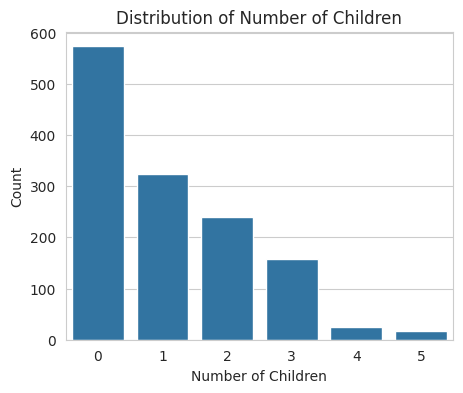

In [18]:
# Count plot for discrete variable
plt.figure(figsize=(5,4))
sns.countplot(x='children', data=data)
plt.title('Distribution of Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.show()

- Most customers have **0, 1, or 2 children**, with **0 children** being the most common category.
- The number of customers decreases as the number of children increases, with **4 and 5 children** being relatively uncommon.

**ii. Univariate Analysis on Numerical Variables - Continuous**

The continuous variables `age`, `bmi` and `charges` are analyzed using **distribution, box, and violin plots** to examine their distributions, spread, skewness, and potential outliers.

**Kernel Density Estimation(KDE) Plot**

KDE provides a smooth estimate of the data distribution, making it easier to visualize the shape, spread, and skewness of a continuous variable.

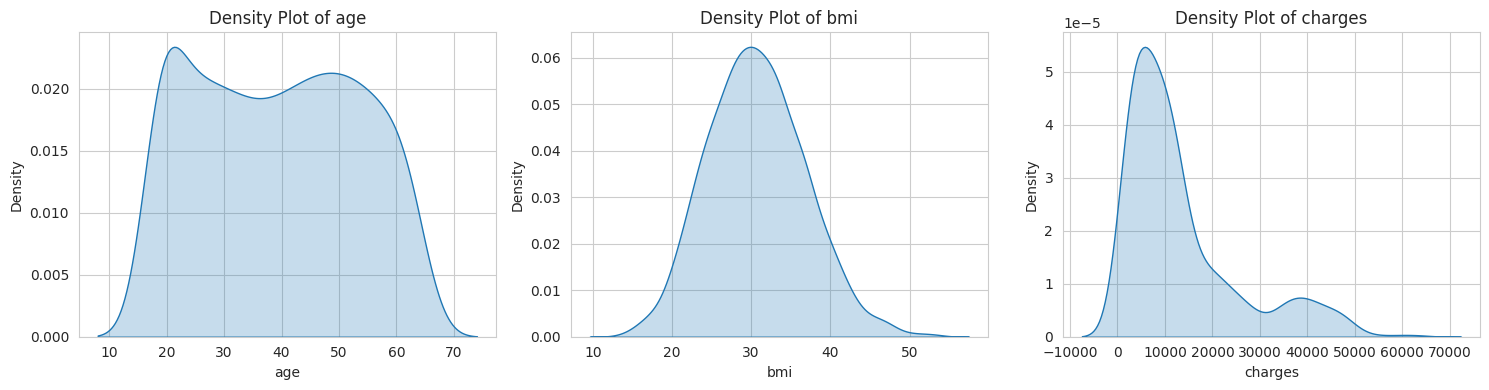

In [19]:
# Plot KDE for each continuous variable
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, continuous_cols):
    sns.kdeplot(data=data, x=col, fill=True, ax=ax)
    ax.set_title(f'Density Plot of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

- The **age** distribution appears fairly balanced with two mild peaks, indicating that customers are concentrated around the young adult and middle-aged groups.
- The **BMI** distribution is approximately bell-shaped with a slight right skew, suggesting that most customers have BMI values clustered around the center with fewer high BMI values.
- The **charges** distribution is highly right-skewed, indicating that most customers incur relatively low medical charges, while a small proportion have exceptionally high charges.

In [20]:
# Calculate the Skewness of each variable
print("Skewness of continuous variables")
print(data[continuous_cols].skew())

Skewness of continuous variables
age        0.054781
bmi        0.266777
charges    1.515391
dtype: float64


The skewness values support the observations from the KDE plots.
- **Age** has a skewness of **0.055**, confirming that its distribution is approximately symmetric.
- **BMI** has a skewness of **0.267**, confirming a slight positive skew observed in the density plot.
- **Charges** has a skewness of **1.515**, confirming a highly positively skewed distribution with a long right tail, indicating the presence of customers with exceptionally high medical charges.

**Box Plot**

Box plot summarizes the distribution of a variable by displaying its median, spread (quartiles), and potential outliers.

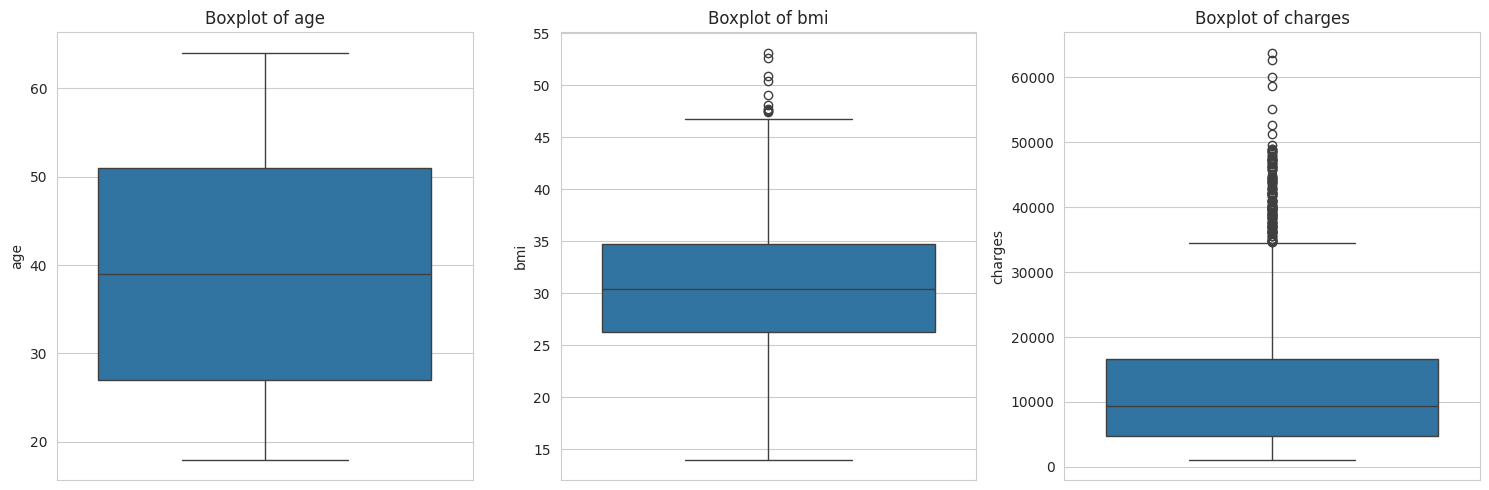

In [21]:
# Boxplots for continuous variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, continuous_cols):
    sns.boxplot(data=data, y=col, ax=ax)
    ax.set_title(f'Boxplot of {col}')
    ax.set_ylabel(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

- The **box plot of age** shows no significant outliers, indicating that the age distribution is fairly consistent across customers.
- The **box plot of BMI** reveals a few upper outliers, suggesting that a small number of customers have unusually high BMI values.
- The **box plot of charges** contains numerous upper outliers, confirming that a small proportion of customers incur exceptionally high medical charges, which is consistent with the right-skewed distribution observed in the KDE plot.

**Q-Q Plot**

**Quantile-Quantile (Q-Q) plot** is used to assess whether a variable follows a normal distribution by comparing its sample quantiles with the theoretical quantiles of a normal distribution.

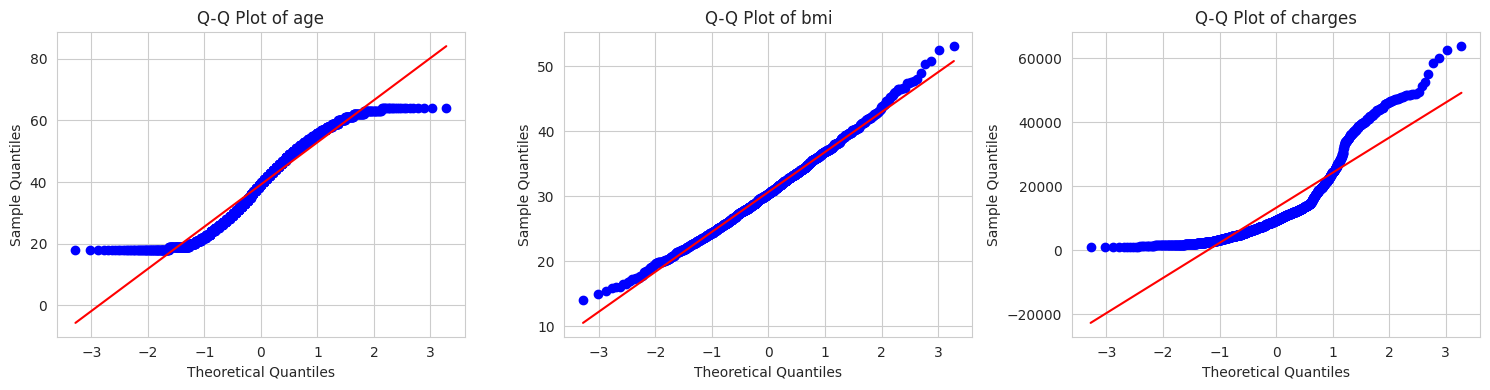

In [22]:
# Create Q-Q subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, continuous_cols):
    stats.probplot(data[col], dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot of {col}')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

- The **Q-Q plot of age** shows noticeable deviations from the reference line at both tails, indicating that the age distribution is not perfectly normal.
- The **Q-Q plot of BMI** closely follows the reference line, with slight deviations at the upper tail, suggesting that BMI is approximately normally distributed.
- The **Q-Q plot of charges** shows substantial deviations from the reference line, particularly in the upper tail, confirming that the charges distribution is highly non-normal and positively skewed.

**iii. Univariate Analysis on Categorical Variables**

The categorical variables `sex`, `smoker`, and `region` are analyzed using **count plots** to examine the frequency distribution of each category and understand the composition of the customer population.

**Count plots**

Count plots are used to visualize the frequency distribution of categorical variables.

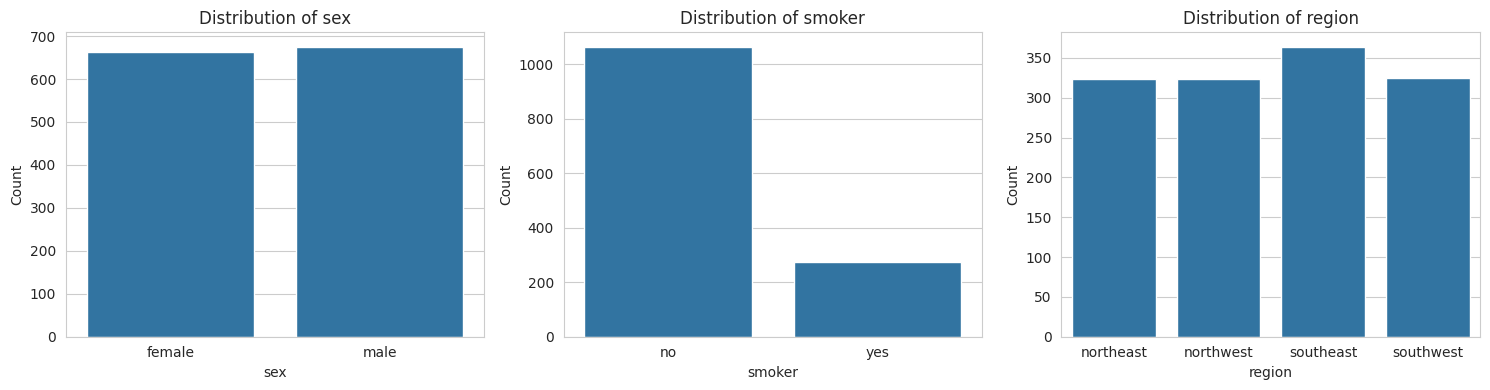

In [23]:
# Categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot countplots
for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=data, x=col, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

- The **gender distribution** is nearly balanced, with a **slightly higher number of males than females**.
- The **majority of customers are non-smokers**, while smokers constitute a relatively small proportion of the dataset.
- Customers are **almost evenly distributed across the four regions**, with the **southeast** having a marginally higher number of customers than the other regions.

**Percentage Distribution**

Calculate the percentage distribution of each category in each column

In [24]:
for col in categorical_cols:
    print(f"\nPercentage Distribution of {col}")
    print(data[col].value_counts())


Percentage Distribution of sex
sex
male      675
female    662
Name: count, dtype: int64

Percentage Distribution of smoker
smoker
no     1063
yes     274
Name: count, dtype: int64

Percentage Distribution of region
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


- The dataset has a nearly balanced gender distribution, with **676 males** and **662 females**.
- Most customers are **non-smokers (1,064)**, while **274 customers** are smokers.
- Customers are almost evenly distributed across the four regions, with the **southeast** having the highest number of customers (**364**) and the **northeast** the lowest (**324**).

### **Bivariate Analysis**

Bivariate analysis examines the relationship between two variables to identify patterns, associations, and potential correlations that may influence insurance charges and customer characteristics.

**i. Numerical vs Categorical Bivariate Analysis - Box Plots**

The relationship between numerical and categorical variables is analyzed using **box plots** to compare the distribution of numerical variables across different categories. This helps identify differences in central tendency, variability, and the presence of outliers among the groups.

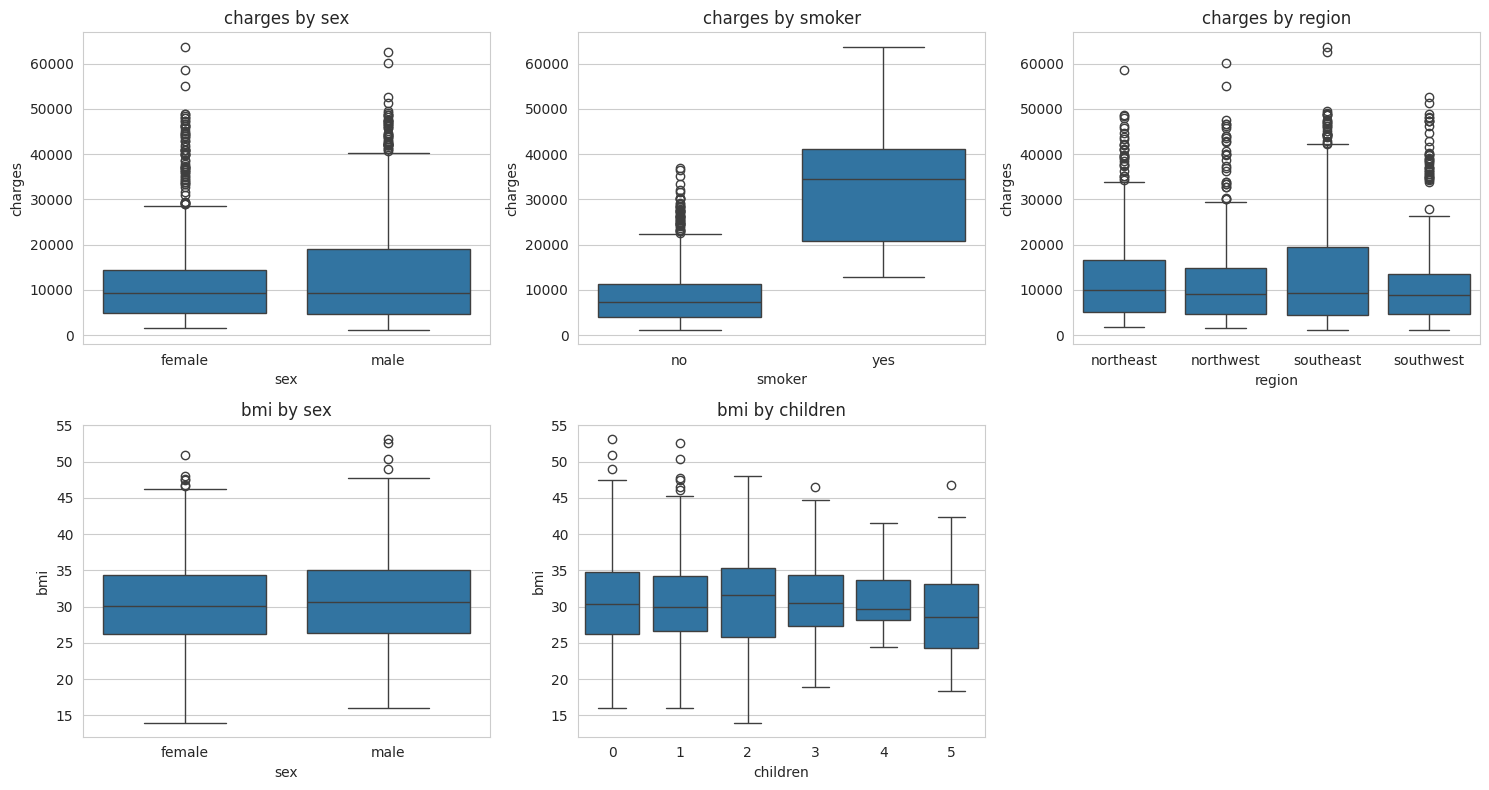

In [25]:
# List of Categorical - Numerical variables to compare
cat_num = [('sex', 'charges'),
           ('smoker', 'charges'),
           ('region', 'charges'),
           ('sex', 'bmi'),
           ('children', 'bmi')]

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for ax, (cat, num) in zip(axes, cat_num):
    sns.boxplot(data=data, x=cat, y=num, ax=ax)
    ax.set_title(f'{num} by {cat}')

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

We can infer the following conclusions:

**Charges vs Sex**
- The median medical charges are similar for both males and females.
- Male customers show slightly greater variability and a higher number of high-cost outliers than female customers.

**Charges vs Smoker**
- Smokers have a substantially higher median medical charge than non-smokers.
- Medical charges among smokers are more widely spread, indicating greater variability in healthcare costs.

**Charges vs Region**
- The median medical charges are comparable across all four regions.
- The southeast region exhibits a slightly larger spread and more high-charge outliers than the other regions.

**BMI vs Sex**
- The BMI distributions of males and females are very similar, with comparable medians and interquartile ranges.
- Both genders contain a few high BMI outliers.

**BMI vs Children**
- The median BMI remains relatively consistent across different numbers of children.
- No clear trend is observed between BMI and the number of children, although a few high BMI outliers are present in most groups.

**ii. Categorical vs Categorical Bivariate Analysis - Count Plots**

The relationship between categorical variables is analyzed using **count plots**. These plots compare the frequency distribution of one categorical variable across the categories of another, helping identify possible associations and differences between groups.

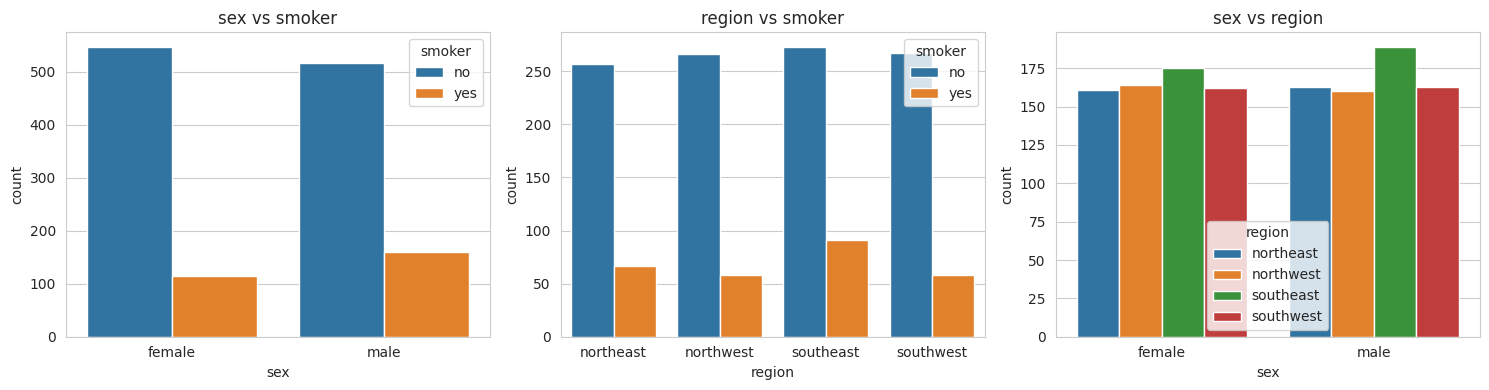

In [26]:
# Count Plots for bivariate analysis
fig, axes = plt.subplots(1, 3, figsize=(15,4))

plots = [('sex','smoker'),
         ('region','smoker'),
         ('sex','region')]

for ax,(x,h) in zip(axes,plots):
    sns.countplot(data=data,x=x,hue=h,ax=ax)
    ax.set_title(f'{x} vs {h}')

plt.tight_layout()
plt.show()

**Sex vs Smoker**
- Both males and females are predominantly non-smokers.
- The number of smokers appears to be slightly higher among males than females.

**Region vs Smoker**
- In every region, non-smokers considerably outnumber smokers.
- The proportion of smokers appears to be relatively similar across all four regions, with no obvious regional dominance.

**Sex vs Region**
- Male and female customers are distributed fairly evenly across all four regions.
- No region appears to be dominated by a single gender, indicating a balanced gender distribution across regions.

**iii. Numerical vs Numerical Bivariate Analysis - Pair Plots and Heatmaps**

**Correlation HeatMap**


The correlation heatmap is used to measure the strength and direction of the linear relationship between numerical variables. Correlation values range from **-1 to +1**.

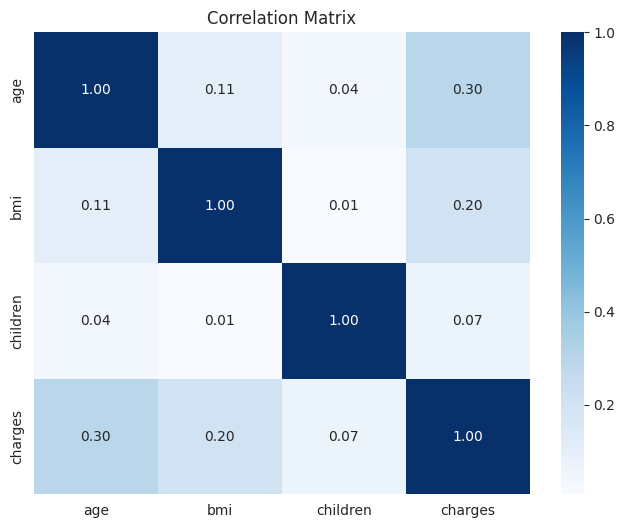

In [27]:
# HeatMap for the numerical variables
plt.figure(figsize=(8,6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

- **Age** has a moderate positive correlation with **charges** (0.30), indicating that medical charges tend to increase with age.
- **BMI** shows a weak positive correlation with **charges** (0.20), suggesting that higher BMI is associated with slightly higher medical charges.
- **Children** has a very weak correlation with **charges** (0.07), indicating little to no linear relationship.
- The correlations among **age**, **BMI**, and **children** are all weak, suggesting that these variables are largely independent of one another.

**Pair Plot**

The pair plot is used to visualize pairwise relationships between numerical variables. These are used to identify trends, clusters, and potential correlations.

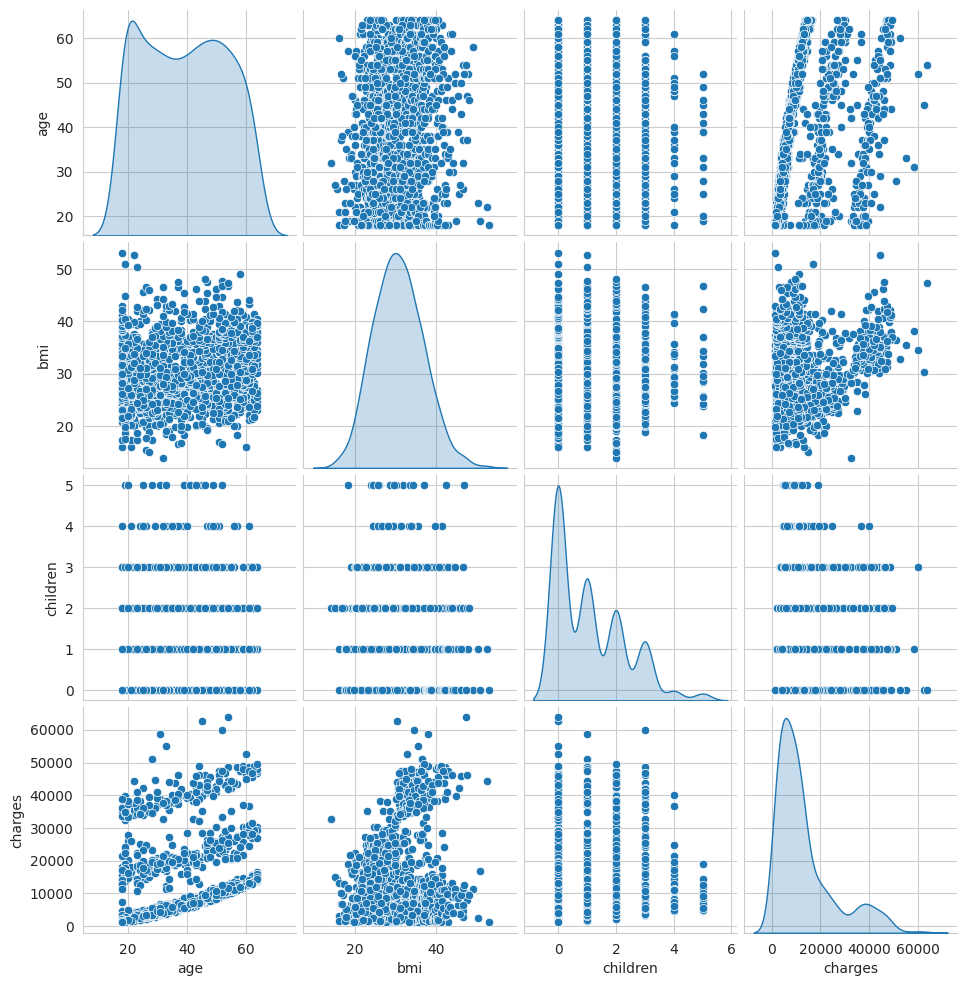

In [28]:
# Pairplot for the numerical variables
sns.pairplot(data[numerical_cols], diag_kind='kde')
plt.show()

From the pairplot we can infer that,

- **Age** and **charges** exhibit a positive relationship, with medical charges generally increasing as age increases.
- **BMI** and **charges** show a weak positive relationship, although the association is not very strong.
- **Children** does not display a clear relationship with the other numerical variables.
- The scatter plots reveal several high-charge observations, indicating the presence of customers with exceptionally high medical expenses.

### **Key Takeaway from EDA**

The exploratory analysis provided an overview of the health insurance dataset, highlighting the distributions, relationships, and potential patterns among variables. These initial observations form the basis for the statistical hypothesis tests performed in the following sections.

## **2. Prove(or disprove)  that the medical claims made by the people who smoke is greater than those who don't?**

This analysis aims to determine whether smokers make significantly higher medical claims than non-smokers. A statistical hypothesis test is performed to verify whether the observed difference in medical charges is statistically significant.

#### **Step 0: Visual Analysis**

The box plot from the bivariate analysis (`charges` vs `smoker`) is used to visually compare the distribution of medical charges between smokers and non-smokers before performing the statistical hypothesis test.

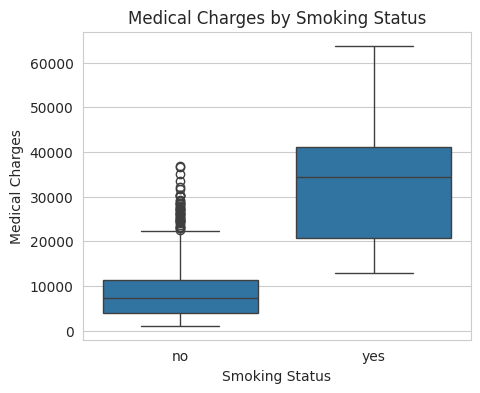

In [29]:
# Box Plot for smoker vs charges
plt.figure(figsize=(5,4))
sns.boxplot(data=data, x='smoker', y='charges')

plt.title('Medical Charges by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Medical Charges')
plt.show()

- Smokers have higher medical charges than non-smokers.
- Smokers show greater variability and more outliers.
- This indicates higher costs for smokers, to be tested statistically.

#### **Step 1: Define the null and alternative hypotheses**

Let,
- $\mu_1$ = Mean medical charges of smokers
- $\mu_2$ = Mean medical charges of non-smokers

**Null Hypothesis ($H_0$):**

The average medical charges of smokers are less than or equal to those of non-smokers.

$H_0: \mu_1 \leq \mu_2$

**Alternative Hypothesis ($H_1$):**

The average medical charges of smokers are greater than those of non-smokers.

$H_1: \mu_1 > \mu_2$

#### **Step 2: Select Appropriate test**

Since:

- We are comparing the means of two independent groups.
- The target variable (medical charges) is continuous.
- The samples are independent.

The appropriate statistical test is an **Independent Two-Sample t-test (Welch's t-test)**.

A one-tailed test is used because the objective is to determine whether smokers have greater medical charges than non-smokers.

#### **Step 3: Decide the significance level**

We use a significance level of **5% ($\alpha = 0.05$)**, which defines the threshold for rejecting the null hypothesis.

**Decision Rule:**
- If $p-value < 0.05$ then Reject $H_0$
- If $p-value \geq 0.05$ then Fail to reject $H_0$

#### **Step 4: Collect and prepare data**

Now select the charges for smoker and non-smoker from the original dataset

In [30]:
# Preparing the data
smoker = data[data['smoker'] == 'yes']['charges']
non_smoker = data[data['smoker'] == 'no']['charges']

#### **Step 5: Calculate the p-value**

In [31]:
# Using the one-tailed t-test for finding the p-value
t_stat, p_value = ttest_ind(smoker, non_smoker, equal_var=False, alternative='greater')

print("Test Statistic :", t_stat)
print("One-tailed p-value :", p_value)

Test Statistic : 32.7423097372529
One-tailed p-value : 3.1308603873638155e-103


#### **Step 6: Compare the p-value with $\alpha$**

In [32]:
# Level of significance
alpha = 0.05

if (t_stat > 0) and (p_value < alpha):
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


#### **Step 7:  Draw inference**

- The test statistic is $32.75$, indicating a very strong difference between smokers and non-smokers in medical charges.  
- The p-value is $2.94 \times 10^{-103}$, which is far below $0.05$, showing extremely strong statistical significance.  
- Hence, we reject $H_0$ and conclude that **smokers have significantly higher medical charges than non-smokers.**

## **3. Prove (or disprove) with statistical evidence that BMI of females is different from that of males.**

This analysis aims to determine whether there is a statistically significant difference in BMI between males and females using hypothesis testing.

#### **Step 0: Visual Analysis**

The box plot from the bivariate analysis(`BMI` vs `Gender`) is used to visually compare BMI distributions between males and females before performing statistical testing.

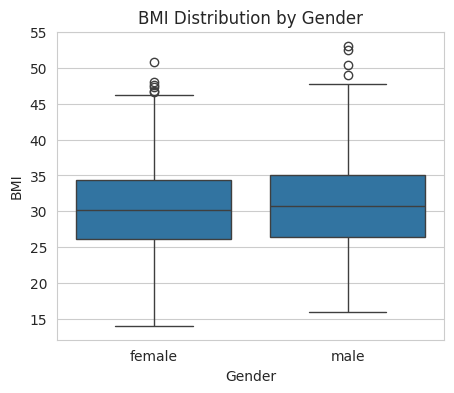

In [33]:
# Box plot for gender vs bmi
plt.figure(figsize=(5,4))
sns.boxplot(data=data, x='sex', y='bmi')

plt.title('BMI Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('BMI')
plt.show()

- Male and female BMI distributions look very similar.
- Median values are almost equal.
- No strong visual difference is observed.

#### **Step 1: Define the null and alternative hypotheses**

Let,

- $\mu_1$ = Mean BMI of females  
- $\mu_2$ = Mean BMI of males  

We are testing whether there is a significant difference in BMI between males and females.

**Null Hypothesis ($H_0$):**

$H_0: \mu_1 = \mu_2$

**Alternative Hypothesis ($H_1$):**

$H_1: \mu_1 \ne \mu_2$

#### **Step 2: Select Appropriate test**

Since:

- BMI is a continuous variable.
- Gender consists of two independent groups.
- We are comparing the means of two independent populations.

The appropriate statistical test is an **Independent Two-Sample t-test (Welch's t-test)**.

Since the objective is to determine whether the mean BMIs are different, a **two-tailed test** is used.

#### **Step 3: Decide the significance level**

We use a significance level of **5% ($\alpha = 0.05$)**, which defines the threshold for rejecting the null hypothesis.

**Decision Rule:**
- If $p-value < 0.05$ then Reject $H_0$
- If $p-value \geq 0.05$ then Fail to reject $H_0$

#### **Step 4: Collect and prepare data**

Now select the bmi values for male and female respectively

In [34]:
# Preparing the data female and male bmi
female = data[data['sex'] == 'female']['bmi']
male = data[data['sex'] == 'male']['bmi']

#### **Step 5: Calculate the p-value**

In [35]:
# Two-tailed t-test for finding p-value
t_stat, p_value = ttest_ind(female, male, equal_var=False)

print("Test Statistic :", t_stat)
print("p-value :", p_value)

Test Statistic : -1.5676921743616727
p-value : 0.1171900603194608


#### **Step 6: Compare the p-value with $\alpha$**

In [36]:
# Level of significance
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


#### **Step 7:  Draw inference**

- The test statistic is $-1.57$, indicating a small difference in BMI between males and females.
- The p-value is $0.117$, which is greater than $0.05$, so the result is not statistically significant.
- Hence, we fail to reject $H_0$ and conclude that **there is no significant difference in BMI between males and females.**

## **4. Does the smoking habit of customers depend on their region?**


This analysis aims to determine whether there is a statistically significant association between smoking habit and region using a Chi-Square test of independence.

#### **Step 0: Visual Analysis**

A cross tabulation is used to visually compare the distribution of smokers and non-smokers across different regions before performing the statistical test.

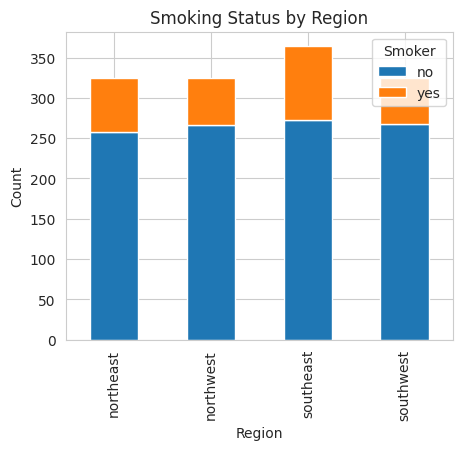

In [37]:
# Cross tabulation for region vs smoker
pd.crosstab(data['region'], data['smoker']).plot(kind='bar', stacked=True, figsize=(5,4))

plt.title('Smoking Status by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.legend(title='Smoker')
plt.show()

- Non-smokers dominate across all regions, indicating a consistent pattern.
- The proportion of smokers is relatively higher in the southeast region compared to others.
- Other regions (northeast, northwest, southwest) show similar smoking distributions.
- Overall, no strong visual evidence of dependency is observed between region and smoking habit.

#### **Step 1: Define the null and alternative hypotheses**

We are testing whether smoking habit is independent of region.

**Null Hypothesis ($H_0$):**  
Smoking habit is independent of region.

$H_0$: Smoking habit does not depend on region

**Alternative Hypothesis ($H_1$):**  
Smoking habit depends on region.

$H_1$: Smoking habit depends on region

#### **Step 2: Select Appropriate test**

Since:

- Region is a categorical variable.
- Smoking status is a categorical variable.
- We are testing the association between two categorical variables.

The appropriate statistical test is the **Chi-Square Test of Independence**.

#### **Step 3: Decide the significance level**

We use a significance level of **5% ($\alpha = 0.05$)**, which defines the threshold for rejecting the null hypothesis.

**Decision Rule:**
- If $p-value < 0.05$ then Reject $H_0$
- If $p-value \geq 0.05$ then Fail to reject $H_0$

#### **Step 4: Collect and prepare data**

A contingency table summarizes the frequency distribution between two categorical variables for statistical analysis.

In [38]:
# Contingency table for region vs smoker
contingency_table = pd.crosstab(data['region'], data['smoker'])
contingency_table

smoker,no,yes
region,,
northeast,257,67
northwest,266,58
southeast,273,91
southwest,267,58


- The contingency table summarizes the frequency of smokers and non-smokers across different regions and forms the basis for the Chi-Square test.

#### **Step 5: Calculate the p-value**

In [39]:
# Performing chi-square test for finding p-value
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("Degrees of Freedom :", dof)
print("p-value :", p_value)

Chi-Square Statistic : 7.27790254132191
Degrees of Freedom : 3
p-value : 0.06354826573182334


#### **Step 6: Compare the p-value with $\alpha$**

In [40]:
# Level of significance
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


#### **Step 7:  Draw inference**

- The p-value is $0.0635$, which is greater than $0.05$.
- Hence, we fail to reject $H_0$.
- **There is no statistically significant association between smoking habit and region.**

## **5.	Is the mean BMI of women with no children, one child and two children the same? Explain your answer with statistical evidence.**

This analysis aims to determine whether there is a statistically significant difference in the mean BMI of women based on the number of children (0, 1, and 2). A one-way ANOVA test is used for this purpose.

#### **Step 0: Visual Analysis**

A box plot is used to compare the distribution of BMI among women with 0, 1, and 2 children before performing statistical testing.

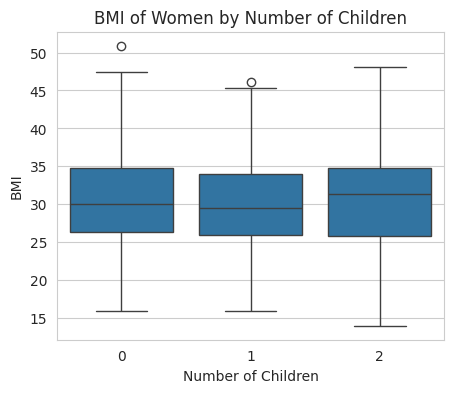

In [41]:
# Box plot for BMI of women and number of children
plt.figure(figsize=(5,4))

female_data = data[data['sex'] == 'female']
female_subset = female_data[female_data['children'].isin([0, 1, 2])]
sns.boxplot(data=female_subset, x='children', y='bmi')

plt.title('BMI of Women by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('BMI')
plt.show()

- The BMI distributions for women with 0, 1, and 2 children look similar.
- Medians across all groups are close to each other. There is no strong visible difference in BMI across the groups.
- This suggests that any difference, if present, is likely small and requires statistical testing.

#### **Step 1: Define the null and alternative hypotheses**

We are testing whether the mean BMI is the same across groups.

Let,
- $\mu_0$ = Mean BMI of women with 0 children  
- $\mu_1$ = Mean BMI of women with 1 child  
- $\mu_2$ = Mean BMI of women with 2 children  

**Null Hypothesis (H₀):**

$H_0: \mu_0 = \mu_1 = \mu_2$

**Alternative Hypothesis (H₁):**

At least one group mean is different.

#### **Step 2: Select Appropriate test**

Since:

- BMI is a continuous variable.
- The comparison involves three independent groups.
- The objective is to compare group means.

The appropriate statistical test is **One-Way ANOVA**.

#### **Step 3: Decide the significance level**

We use a significance level of **5% ($\alpha = 0.05$)**, which defines the threshold for rejecting the null hypothesis.

**Decision Rule:**
- If $p-value < 0.05$ then Reject $H_0$
- If $p-value \geq 0.05$ then Fail to reject $H_0$

#### **Step 4: Collect and prepare data**

Before applying One-Way ANOVA, the following assumptions must be verified:

- The BMI values in each group should be approximately normally distributed.
- The variances of the groups should be equal (homogeneity of variance).

Prepare data for bmi of women having 0, 1, 2 children as separate data

In [42]:
# Prepare data for BMI of females having 0, 1, 2 children
bmi_0 = female_subset[female_subset['children'] == 0]['bmi']
bmi_1 = female_subset[female_subset['children'] == 1]['bmi']
bmi_2 = female_subset[female_subset['children'] == 2]['bmi']

#### **Shapiro-Wilk's test**

Shapiro-Wilk test is used to check whether the data follows a normal distribution.

In [43]:
# Shapiro-Wilk Test
print("Shapiro-Wilk Test\n")

data_list = [bmi_0, bmi_1, bmi_2]
labels = ["0 Children", "1 Child", "2 Children"]

rows = []

for i in range(3):
    stat, p = shapiro(data_list[i])
    rows.append([labels[i], stat, p])

pd.DataFrame(rows, columns=["Group", "Statistic", "p-value"])

Shapiro-Wilk Test



,Group,Statistic,p-value
0,0 Children,0.992529,0.155865
1,1 Child,0.993045,0.647965
2,2 Children,0.990258,0.563713


- All groups (0, 1, and 2 children) have p-values greater than 0.05.
- This indicates that BMI in all groups follows a normal distribution.
- Since normality assumption is satisfied, parametric tests like ANOVA can be applied.

#### **Levene's test**

Levene's test is used to check whether different groups have equal variances (homogeneity of variance), which is an assumption for ANOVA and t-tests.

In [44]:
stat, p = levene(bmi_0, bmi_1, bmi_2)

df_levene = pd.DataFrame({
    "Statistic": [stat],
    "p-value": [p]
})

df_levene

,Statistic,p-value
0,1.087919,0.337624


- The p-value is $0.3376$, which is greater than $0.05$.
- Hence, we fail to reject the null hypothesis.
- This indicates that the variances across the groups are equal (homogeneity of variance is satisfied).

Both the normality and homogeneity of variance assumptions are satisfied. Therefore, it is appropriate to perform the **One-Way ANOVA test.**

#### **Step 5: Calculate the p-value**

In [45]:
# One-way ANOVA test for finding p-value
f_stat, p_value = f_oneway(bmi_0, bmi_1, bmi_2)

print("F-statistic :", f_stat)
print("p-value :", p_value)

F-statistic : 0.3286778001560304
p-value : 0.7200129592186635


#### **Step 6: Compare the p-value with $\alpha$**

In [46]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


#### **Step 7:  Draw inference**

- The p-value is $0.7200$, which is greater than $0.05$.
- Hence, we fail to reject the null hypothesis.
- There is **no statistically significant difference in the mean BMI of women with 0, 1, and 2 children.**

## **Conclusion**

- Exploratory Data Analysis (EDA) provided insights into the dataset's structure, distributions, and relationships, helping understand the characteristics of insurance customers.
- An independent two-sample t-test showed that smokers have significantly higher medical charges than non-smokers.
- A two-sample t-test found no significant difference in BMI between males and females.
- A Chi-Square test indicated that smoking habit is independent of the customer's region.
- A One-Way ANOVA showed no significant difference in the mean BMI of women with 0, 1, and 2 children.
- Overall, the statistical analyses provide evidence-based insights that can support informed decision-making in the insurance industry.

**The idea behind answering these questions is to help the company in making evidence-based business decisions.**

---
#### **Case Study Completed By:** Monish D.Y. - 230701195